<a href="https://colab.research.google.com/github/code-by-anastasiia/Neural-Networks/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
x_train, x_test = x_train / 255.0, x_test / 255.0

/tmp/ipython-input-2539800468.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(class_names[int(y_train[i])])


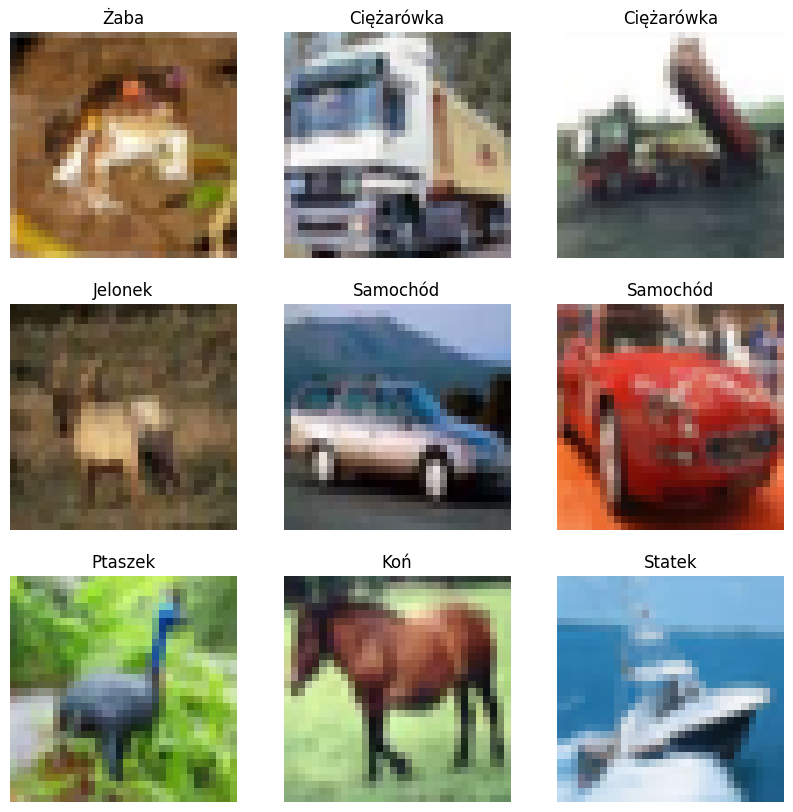

In [6]:
class_names = ["Samolot", "Samochód", "Ptaszek", "Kot", "Jelonek", "Pies",
               "Żaba", "Koń", "Statek", "Ciężarówka"]

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis("off")
plt.show()

In [7]:
# model CNN
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [11]:
history = model.fit(x_train, y_train,
                    epochs=10,
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 45ms/step - accuracy: 0.2499 - loss: 2.5950 - val_accuracy: 0.4508 - val_loss: 1.4845
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 43ms/step - accuracy: 0.4974 - loss: 1.3828 - val_accuracy: 0.5603 - val_loss: 1.2459
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.5785 - loss: 1.1973 - val_accuracy: 0.5687 - val_loss: 1.2377
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6125 - loss: 1.0944 - val_accuracy: 0.6140 - val_loss: 1.1020
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6514 - loss: 0.9953 - val_accuracy: 0.6225 - val_loss: 1.0884
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 69s 44ms/step - accuracy: 0.6725 - loss: 0.9392 - val_accuracy: 0.6530 - val_loss: 1.0389
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7005 - loss: 0.8641 - val_accuracy: 0.6608 - val_loss: 0.9926
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 68s 43ms/step - accuracy: 0.7206 -

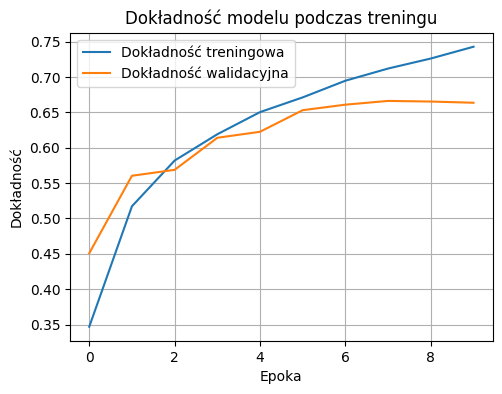

In [14]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Dokładność treningowa')
plt.plot(history.history['val_accuracy'], label='Dokładność walidacyjna')
plt.xlabel('Epoka')
plt.ylabel('Dokładność')
plt.legend()
plt.title('Dokładność modelu podczas treningu')
plt.grid(True)
plt.show()

In [15]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print("Test accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6623 - loss: 1.0531
Test accuracy: 0.6635000109672546


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


/tmp/ipython-input-3861641457.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.title(f"True: {class_names[int(y_test[i])]}," +


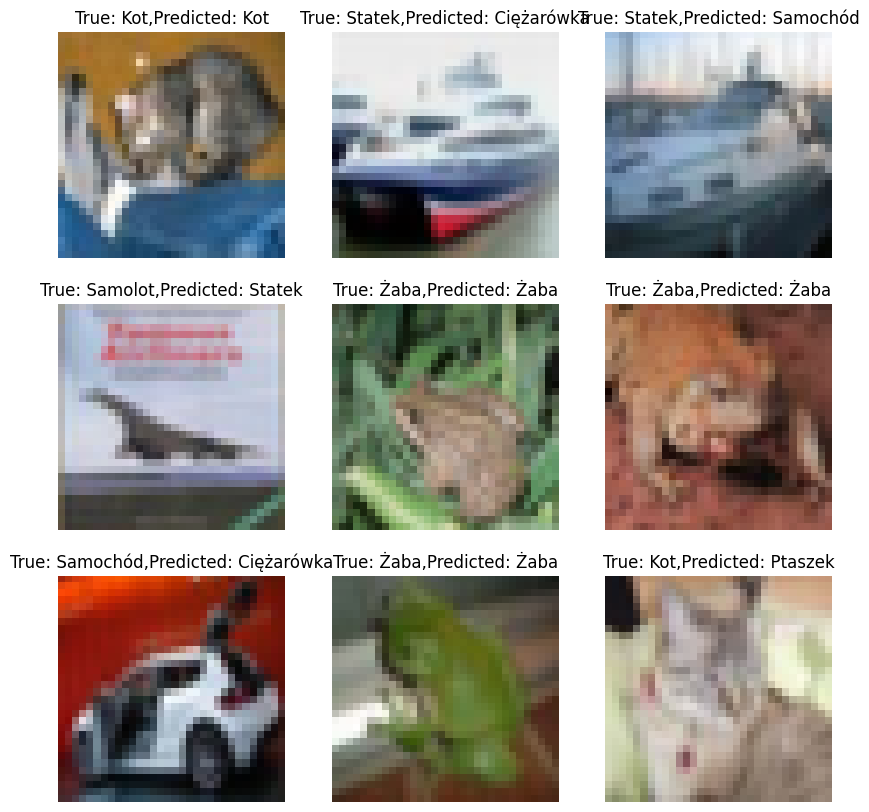

In [16]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 10))
for i in range(9):
  plt.subplot(3, 3, i + 1)
  plt.imshow(x_test[i])
  plt.title(f"True: {class_names[int(y_test[i])]}," +
f"Predicted: {class_names[tf.argmax(predictions[i])]}")
  plt.axis("off")
plt.show()

Zadanie 1: Dodanie dodatkowych warstw konwolucyjnych

In [17]:
model_extra_conv = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_extra_conv.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

model_extra_conv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,314 (1.05 MB)

 Trainable params: 274,314 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history_extra_conv = model_extra_conv.fit(x_train, y_train,
                                          epochs=10,
                                          validation_data=(x_test, y_test),
                                          verbose=1)

test_loss_extra, test_acc_extra = model_extra_conv.evaluate(x_test, y_test, verbose=0)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 95s 61ms/step - accuracy: 0.8280 - loss: 0.4961 - val_accuracy: 0.6633 - val_loss: 1.1526
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.8432 - loss: 0.4528 - val_accuracy: 0.6686 - val_loss: 1.1879
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.8517 - loss: 0.4285 - val_accuracy: 0.6601 - val_loss: 1.2733
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.8631 - loss: 0.3947 - val_accuracy: 0.6649 - val_loss: 1.3028
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 145s 59ms/step - accuracy: 0.8756 - loss: 0.3652 - val_accuracy: 0.6647 - val_loss: 1.3021
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 139s 57ms/step - accuracy: 0.8842 - loss: 0.3371 - val_accuracy: 0.6641 - val_loss: 1.3570
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.8932 - loss: 0.3168 - val_accuracy: 0.6717 - val_loss: 1.4109
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 91s 58ms/step - accuracy: 0.8972

In [26]:
test_loss_extra, test_acc_extra = model_extra_conv.evaluate(x_test, y_test)
print(f"Model z dodatkowymi warstwami - Test accuracy: {test_acc_extra:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6661 - loss: 1.6099
Model z dodatkowymi warstwami - Test accuracy: 0.6694


Zadanie 2: Dropout

In [20]:
model_dropout = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dropout.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

model_dropout.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history_dropout = model_dropout.fit(x_train, y_train,
                                   epochs=10,
                                   validation_data=(x_test, y_test),
                                   verbose=1)

test_loss_dropout, test_acc_dropout = model_dropout.evaluate(x_test, y_test, verbose=0)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 50ms/step - accuracy: 0.0973 - loss: 3.6916 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 49ms/step - accuracy: 0.1004 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 49ms/step - accuracy: 0.0972 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.0959 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 50ms/step - accuracy: 0.0979 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 77s 49ms/step - accuracy: 0.0971 - loss: 2.3155 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 48ms/step - accuracy: 0.0974 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.1031 -

In [27]:
test_loss_dropout, test_acc_dropout = model_dropout.evaluate(x_test, y_test)
print(f"Model z Dropout - Test accuracy: {test_acc_dropout:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0988 - loss: 2.3039
Model z Dropout - Test accuracy: 0.1000


Zadanie 3: Zmiana funkcji aktywacji

In [22]:
# Model z funkcją aktywacji tanh zamiast relu
model_tanh = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(32, 32, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation='tanh'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='tanh'),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation='tanh'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='tanh'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_tanh.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_tanh.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("Trening modelu z funkcją tanh...")
history_tanh = model_tanh.fit(x_train, y_train,
                              epochs=10,
                              validation_data=(x_test, y_test),
                              verbose=1)

test_loss_tanh, test_acc_tanh = model_tanh.evaluate(x_test, y_test, verbose=0)

Trening modelu z funkcją tanh...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 47ms/step - accuracy: 0.3732 - loss: 1.7345 - val_accuracy: 0.4904 - val_loss: 1.4130
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5122 - loss: 1.3711 - val_accuracy: 0.5328 - val_loss: 1.3142
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.5512 - loss: 1.2662 - val_accuracy: 0.5510 - val_loss: 1.2622
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 46ms/step - accuracy: 0.5747 - loss: 1.1965 - val_accuracy: 0.5668 - val_loss: 1.2285
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.5839 - loss: 1.1751 - val_accuracy: 0.5650 - val_loss: 1.2256
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 72s 46ms/step - accuracy: 0.5975 - loss: 1.1347 - val_accuracy: 0.5841 - val_loss: 1.1621
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 47ms/step - accuracy: 0.6090 - loss: 1.1085 - val_accuracy: 0.5787 - val_loss: 1.1870
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8

In [28]:
test_loss_tanh, test_acc_tanh = model_tanh.evaluate(x_test, y_test)
print(f"Model z tanh - Test accuracy: {test_acc_tanh:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6040 - loss: 1.1278
Model z tanh - Test accuracy: 0.5969


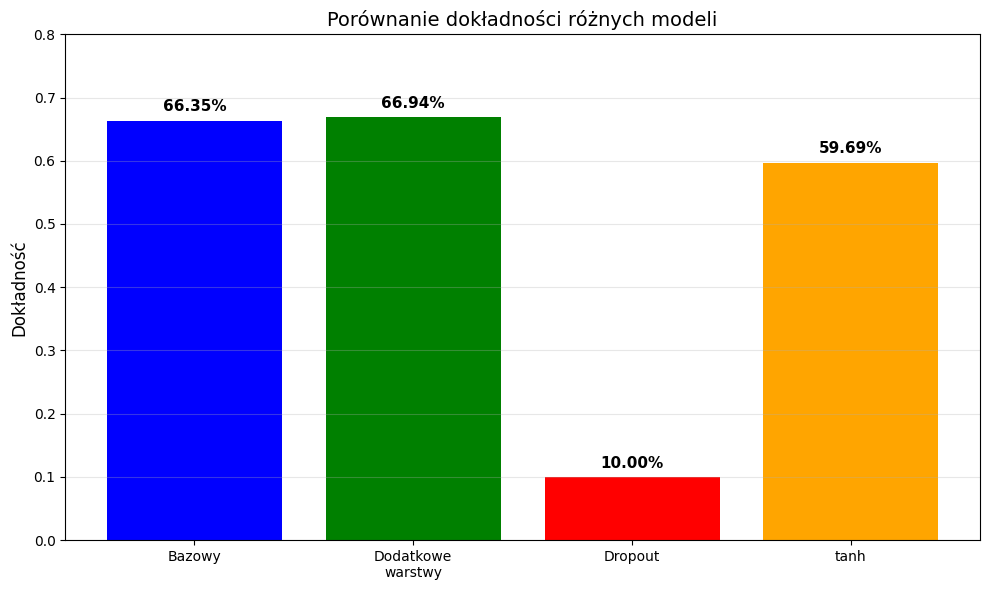

In [30]:
import matplotlib.pyplot as plt

models_names = ['Bazowy', 'Dodatkowe\nwarstwy', 'Dropout', 'tanh']
accuracies = [0.6635, 0.6694, 0.1000, 0.5969]

plt.figure(figsize=(10, 6))
colors = ['blue', 'green', 'red', 'orange']
bars = plt.bar(models_names, accuracies, color=colors)

plt.ylabel('Dokładność', fontsize=12)
plt.title('Porównanie dokładności różnych modeli', fontsize=14)
plt.ylim([0, 0.8])
plt.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{acc:.2%}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Wyniki:

| Model | Dokładność |
|-------|-----------|
| Bazowy | 66.35% |
| Dodatkowe warstwy | 66.94% (najlepszy) |
| Dropout | 10.00% (najgorszy) |
| Tanh | 59.69% |

---

Wpływ modyfikacji na dokładność

Dodatkowe warstwy:
- Poprawiły wynik o 0.59%
- Więcej warstw = model lepiej rozpoznaje złożone obiekty
- Model był stabilny

Dropout:
- Całkowita katastrofa - model niczego się nie nauczył
- Wartości Dropout były zbyt wysokie
- Dropout źle zastosowany blokuje uczenie

Funkcja tanh:
- Pogorszyła wynik o 6.66%
- Tanh działa gorzej niż ReLU w sieciach CNN
- ReLU jest lepszym wyborem

---

Które modyfikacje miały największy wpływ?

- Pozytywny: Dodatkowe warstwy (+0.59%)
- Negatywny: Dropout (-56.35%)

---

Obserwacje

Co działa:
- Więcej warstw Conv poprawia wyniki
- ReLU jest lepsza niż tanh
- Proste modele często działają lepiej

Co nie działa:
- Zbyt wysoki Dropout
- Funkcja tanh w CNN
- Skomplikowane architektury nie zawsze pomagają

---

Podsumowanie

Najlepszy model miał dodatkowe warstwy (66.94%).

Wnioski:
- CNN potrzebują dobrej konfiguracji
- Sprawdzone rozwiązania (ReLU, więcej warstw) działają najlepiej
- Złe parametry mogą całkowicie zniszczyć model
- Dla małych obrazów prostsze sieci są wystarczające